In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

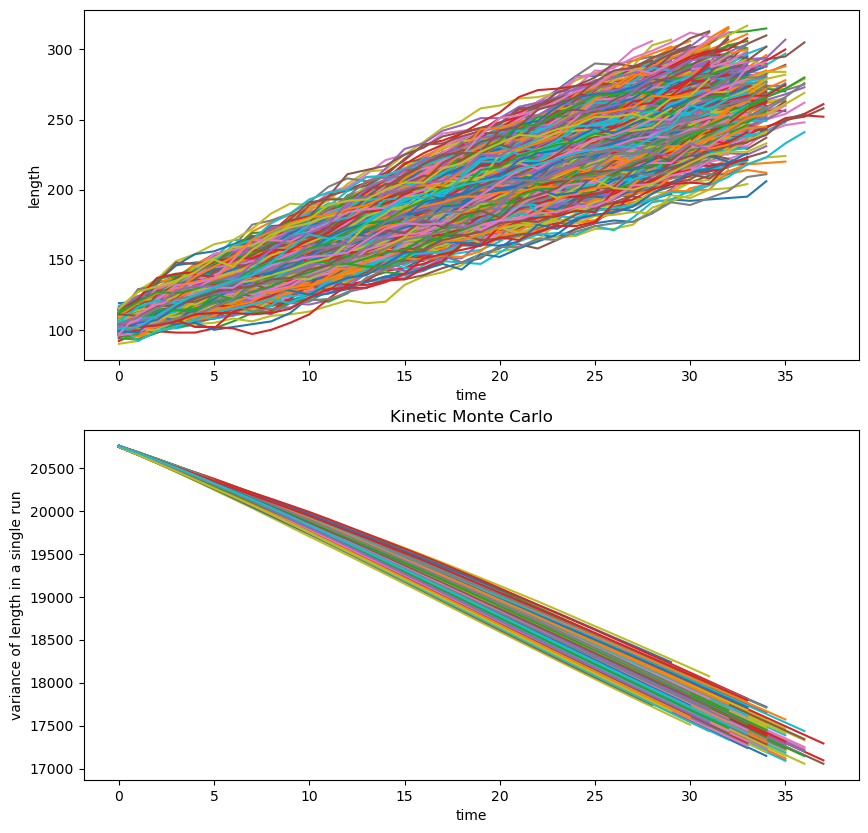

In [2]:
all_lengths = []
all_vars = []
min_t = 2000
steps = 500
N = 1000
for j in range(N):
    kon = 10
    koff = 5
    t = 0
    pon = kon/(kon+koff)
    poff = koff/(kon+koff)
    x = 100
    lengths = [x for x in range(steps)] #time Units
    times = [x for x in range(steps)]
    var = [x for x in range(steps)]
    # lengths = []
    # times = []
    # var = []
    for i in range(steps):
        rand = np.random.random()
        if rand < pon:
            x += 1
        else:
            x -= 1
        delta_t = - np.log(np.random.random()) / (kon+koff)
        t += delta_t
        sigma_sq = np.average(np.array(lengths)**2) - (np.average(lengths))**2
        # lengths.append(x)
        # times.append(t)
        # var.append(sigma_sq)
        for i in range(math.floor(t-delta_t),math.floor(t+1)):
            lengths[i] = x
            var[i] = sigma_sq
            times[i] = i
    
    lengths = lengths[:math.floor(t)]
    times = times[:math.floor(t)]
    var = var[:math.floor(t)]
    min_t = t if t < min_t else min_t

    all_lengths.append(lengths)
    all_vars.append(var)
    ax0 = plt.subplot(211)
    ax0.figure.set_size_inches(10,10)
    ax1 = plt.subplot(212)
    ax1.figure.set_size_inches(10,10)
    ax0.plot(times,lengths,label=f"i = {j}")
    ax1.plot(times,var,label=f"i = {j}")
    ax0.set_xlabel('time')
    ax1.set_xlabel('time')
    ax0.set_ylabel('length')
    ax1.set_ylabel('variance of length in a single run')

plt.title("Kinetic Monte Carlo")
# plt.legend()
plt.show()

for lengths in all_lengths:
    all_lengths[all_lengths.index(lengths)] = lengths[:math.floor(min_t)]
for vars in all_vars:
    all_vars[all_vars.index(vars)] = vars[:math.floor(min_t)]
times = times[:math.floor(min_t)]

Slope:  4.9952556102900925 
Intercept:  104.96833497536942


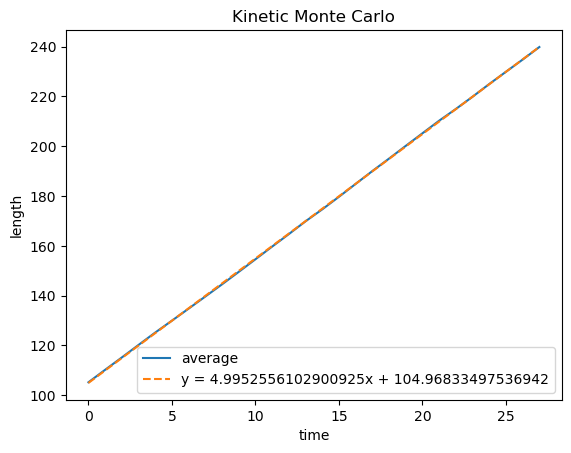

In [3]:
len_t = np.average(np.array(all_lengths),axis=0)
plt.plot(times,len_t,label="average")
plt.xlabel('time')
plt.ylabel('length')
plt.title("Kinetic Monte Carlo")
slope, intercept = np.polyfit(times, len_t, 1)
print("Slope: ", slope,"\nIntercept: ", intercept)
plt.plot(times,np.array(times)*slope+intercept,label=f"y = {slope}x + {intercept}",linestyle='dashed')
plt.legend()
plt.show()

Slope of curve of lengths is nearly 5. Which is kon - koff

Slope:  15.164737877941885 
Intercept:  9.526888004926448


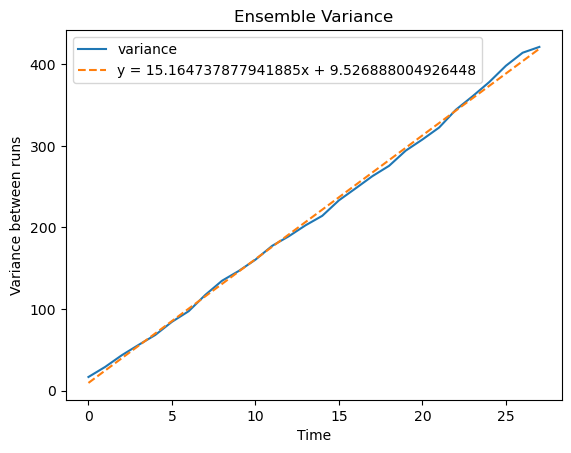

In [4]:
var_t = np.average(np.array(all_lengths)**2,axis=0) - np.average(all_lengths,axis=0)**2
plt.plot(times, var_t,label="variance")
# plt.plot(times, np.array(times)*15,label='expected variance',linestyle='dashed')
plt.ylabel('Variance between runs')
plt.xlabel('Time')
plt.title("Ensemble Variance")
slope, intercept = np.polyfit(times, var_t, 1)
print("Slope: ", slope,"\nIntercept: ", intercept)
plt.plot(times,np.array(times)*slope+intercept,label=f"y = {slope}x + {intercept}",linestyle='dashed')
plt.legend()
plt.show()

Curve of variance is nearly 15. Which is kon+koff